# Cleaned Mental Health Dataset - Exploratory Data Analysis (EDA)

This notebook performs comprehensive exploratory data analysis (EDA) and visualization on the cleaned dataset `mental_health_cleaned.csv`. It covers:
1. Distribution plots for scale scores with clinical severity thresholds.
2. Count plots for Stress, Anxiety, and Depression labels.
3. Inter-scale correlation heatmap and pairwise scatter plots.
4. Item-level boxplots and variance analysis.
5. Demographic splits by Gender, Academic Year, and Age group.
6. Comorbidity crosstab heatmaps.
7. Deep-dive inspection of the CGPA = 'Other' group.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set standard visualization theme and context
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.figsize': (10, 6),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 100,
    'savefig.dpi': 150
})

# Consistent custom HSL-tailored palette mapping for labels
stress_palette = {
    'Low Stress': '#5C97BF',
    'Moderate Stress': '#F5AB35',
    'High Perceived Stress': '#D24D57'
}

anxiety_palette = {
    'Minimal Anxiety': '#A2DED0',
    'Mild Anxiety': '#4DAF7C',
    'Moderate Anxiety': '#F5AB35',
    'Severe Anxiety': '#D24D57'
}

depression_palette = {
    'Minimal Depression': '#A2DED0',
    'Mild Depression': '#4DAF7C',
    'Moderate Depression': '#F5AB35',
    'Moderately Severe Depression': '#EB9532',
    'Severe Depression': '#D24D57'
}

# Load the cleaned dataset
data_path = "mental_health_cleaned.csv"
if not os.path.exists(data_path):
    print(f"Error: '{data_path}' not found.")
else:
    df = pd.read_csv(data_path)
    print(f"Dataset successfully loaded! Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

Dataset successfully loaded! Shape: 2032 rows, 39 columns.


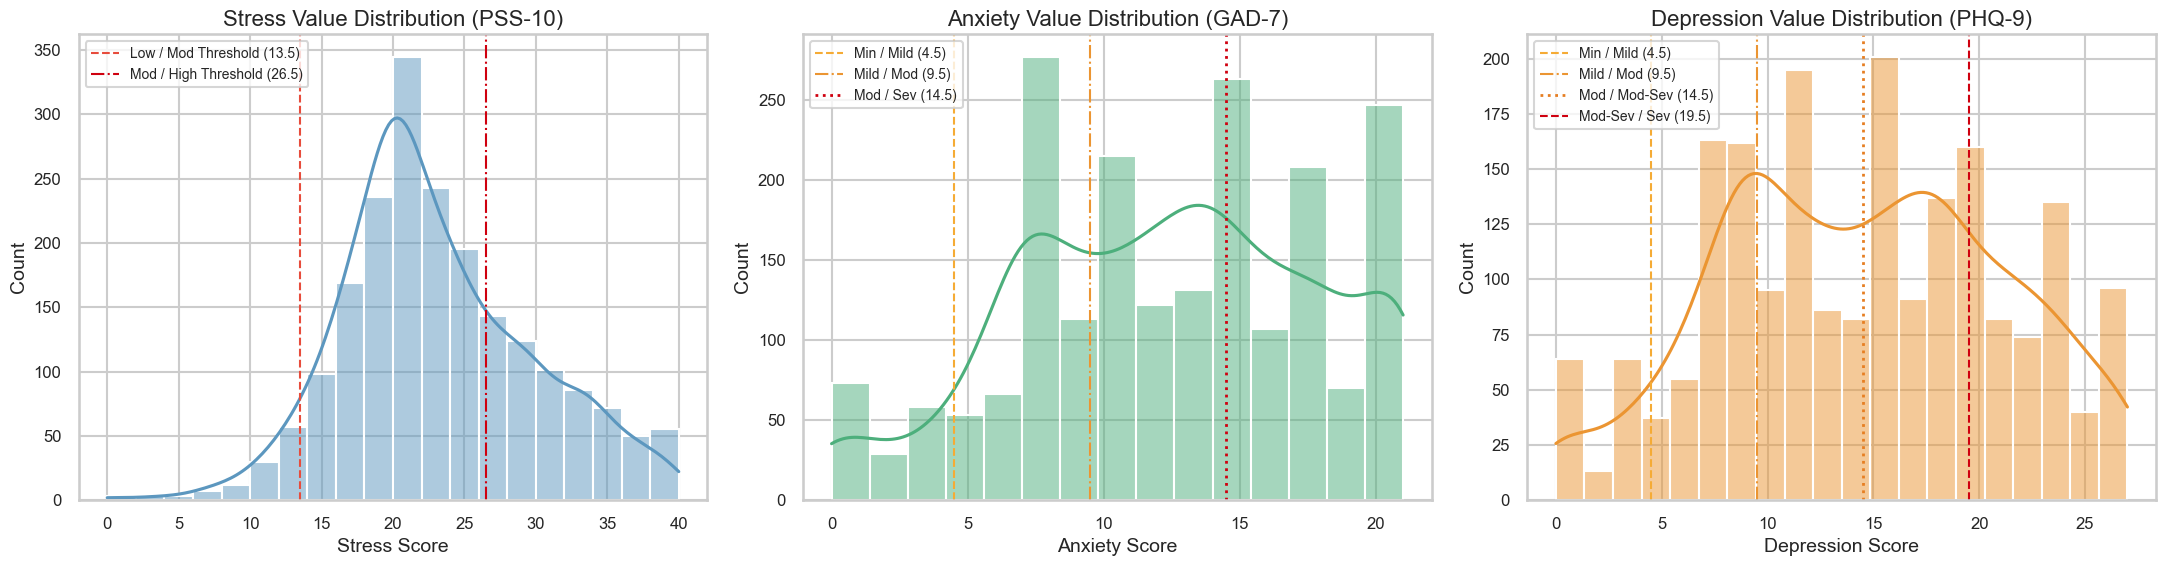

In [2]:
# 1. DISTRIBUTION PLOTS (Histogram + KDE with Thresholds)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Stress Value (PSS-10)
sns.histplot(data=df, x='Stress Value', kde=True, color='#5C97BF', ax=axes[0], bins=20)
axes[0].axvline(13.5, color='#E74C3C', linestyle='--', linewidth=1.5, label='Low / Mod Threshold (13.5)')
axes[0].axvline(26.5, color='#CF000F', linestyle='-.', linewidth=1.5, label='Mod / High Threshold (26.5)')
axes[0].set_title('Stress Value Distribution (PSS-10)')
axes[0].set_xlabel('Stress Score')
axes[0].legend(fontsize=10, loc='upper left')

# Anxiety Value (GAD-7)
sns.histplot(data=df, x='Anxiety Value', kde=True, color='#4DAF7C', ax=axes[1], bins=15)
axes[1].axvline(4.5, color='#F5AB35', linestyle='--', linewidth=1.5, label='Min / Mild (4.5)')
axes[1].axvline(9.5, color='#EB9532', linestyle='-.', linewidth=1.5, label='Mild / Mod (9.5)')
axes[1].axvline(14.5, color='#CF000F', linestyle=':', linewidth=2.0, label='Mod / Sev (14.5)')
axes[1].set_title('Anxiety Value Distribution (GAD-7)')
axes[1].set_xlabel('Anxiety Score')
axes[1].legend(fontsize=10, loc='upper left')

# Depression Value (PHQ-9)
sns.histplot(data=df, x='Depression Value', kde=True, color='#EB9532', ax=axes[2], bins=20)
axes[2].axvline(4.5, color='#F5AB35', linestyle='--', linewidth=1.5, label='Min / Mild (4.5)')
axes[2].axvline(9.5, color='#EB9532', linestyle='-.', linewidth=1.5, label='Mild / Mod (9.5)')
axes[2].axvline(14.5, color='#E67E22', linestyle=':', linewidth=2.0, label='Mod / Mod-Sev (14.5)')
axes[2].axvline(19.5, color='#CF000F', linestyle='--', linewidth=1.5, label='Mod-Sev / Sev (19.5)')
axes[2].set_title('Depression Value Distribution (PHQ-9)')
axes[2].set_xlabel('Depression Score')
axes[2].legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

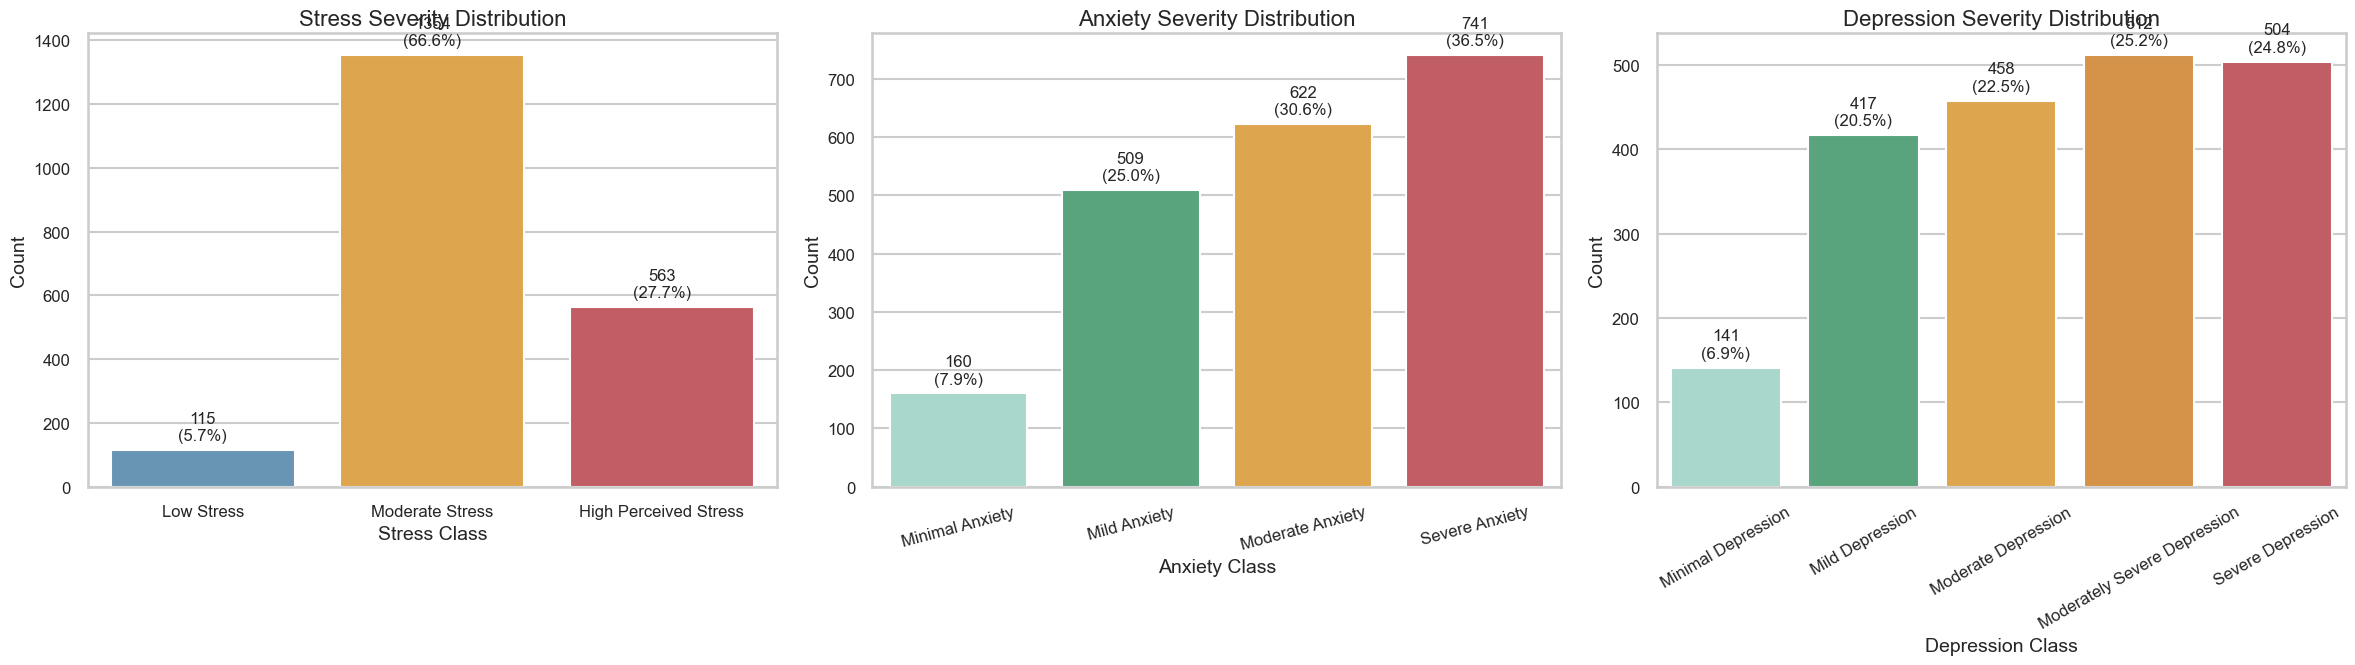

In [3]:
# 2. CLASS DISTRIBUTION (Count plots showing count & percentage)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Stress Label
stress_order = ['Low Stress', 'Moderate Stress', 'High Perceived Stress']
sns.countplot(data=df, x='Stress Label', order=stress_order, hue='Stress Label', palette=stress_palette, legend=False, ax=axes[0])
axes[0].set_title('Stress Severity Distribution')
axes[0].set_xlabel('Stress Class')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    height = p.get_height()
    pct = (height / len(df)) * 100
    axes[0].annotate(f'{int(height)}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

# Anxiety Label
anxiety_order = ['Minimal Anxiety', 'Mild Anxiety', 'Moderate Anxiety', 'Severe Anxiety']
sns.countplot(data=df, x='Anxiety Label', order=anxiety_order, hue='Anxiety Label', palette=anxiety_palette, legend=False, ax=axes[1])
axes[1].set_title('Anxiety Severity Distribution')
axes[1].set_xlabel('Anxiety Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    height = p.get_height()
    pct = (height / len(df)) * 100
    axes[1].annotate(f'{int(height)}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

# Depression Label
depression_order = ['Minimal Depression', 'Mild Depression', 'Moderate Depression', 'Moderately Severe Depression', 'Severe Depression']
sns.countplot(data=df, x='Depression Label', order=depression_order, hue='Depression Label', palette=depression_palette, legend=False, ax=axes[2])
axes[2].set_title('Depression Severity Distribution')
axes[2].set_xlabel('Depression Class')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=30)
for p in axes[2].patches:
    height = p.get_height()
    pct = (height / len(df)) * 100
    axes[2].annotate(f'{int(height)}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

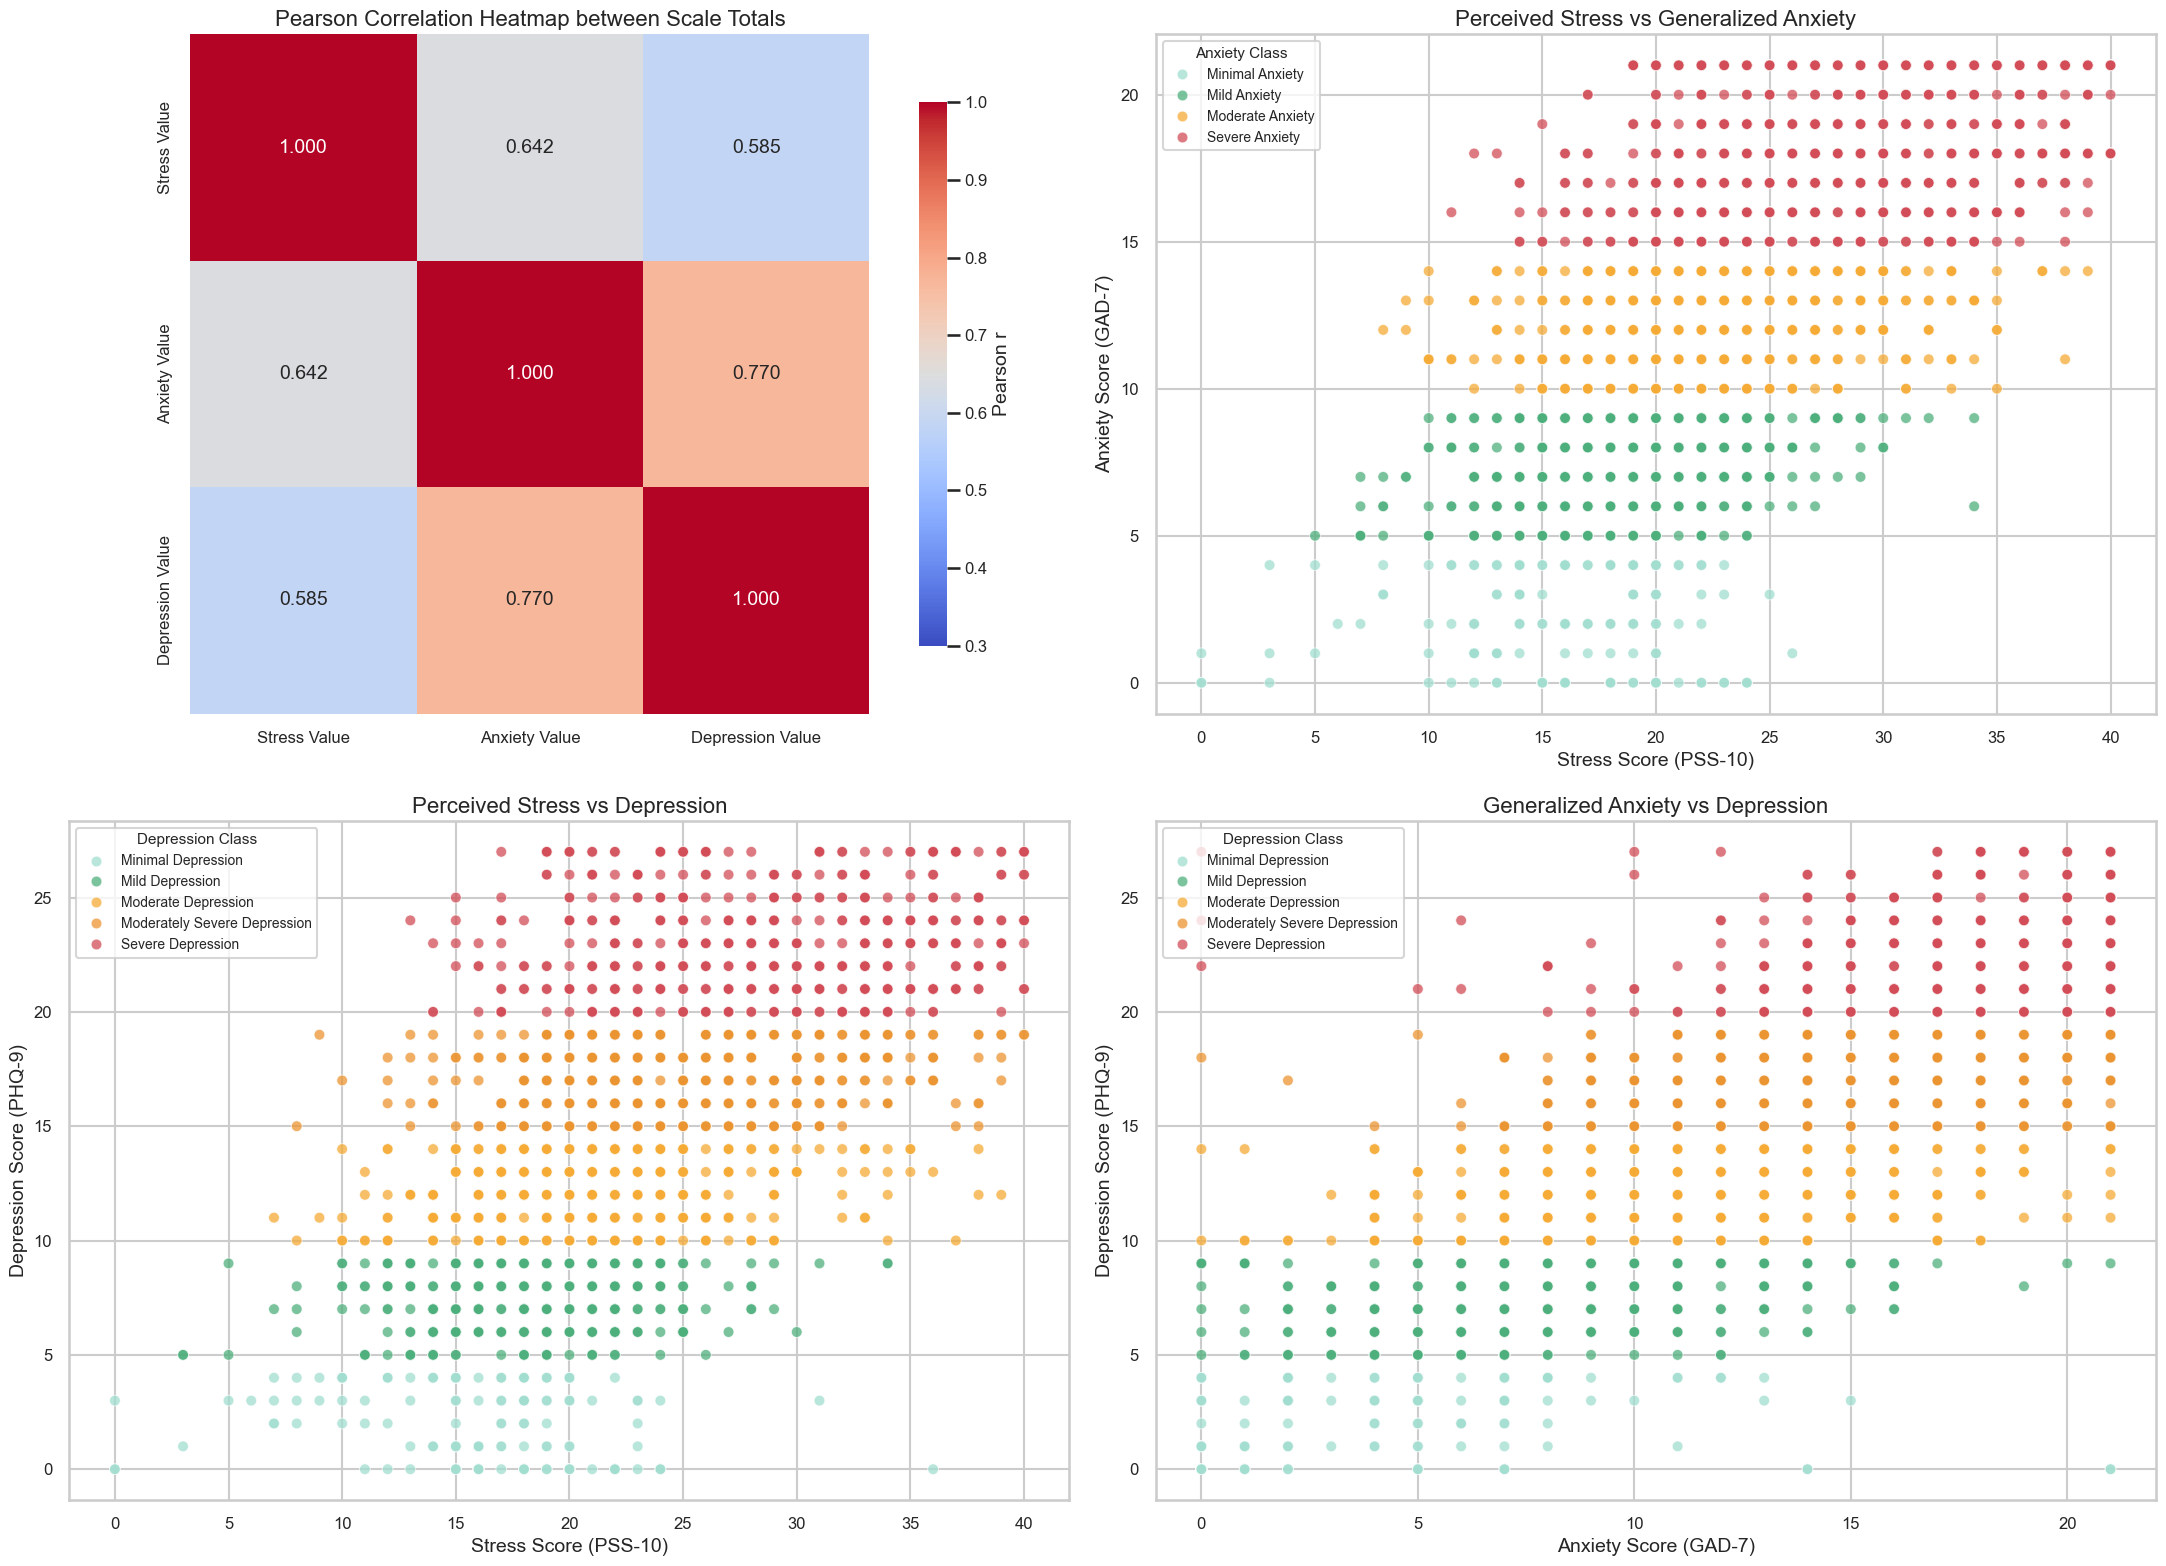

In [4]:
# 3. INTER-SCALE CORRELATION
fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(2, 2)

# Pearson Heatmap
ax_heat = fig.add_subplot(gs[0, 0])
corr = df[['Stress Value', 'Anxiety Value', 'Depression Value']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=0.3, vmax=1.0, square=True,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}, annot_kws={'size': 14}, ax=ax_heat)
ax_heat.set_title('Pearson Correlation Heatmap between Scale Totals', fontsize=16)

# Scatter 1: Stress vs Anxiety (coloured by Anxiety Label)
ax_sc1 = fig.add_subplot(gs[0, 1])
sns.scatterplot(data=df, x='Stress Value', y='Anxiety Value', hue='Anxiety Label', 
                hue_order=anxiety_order, palette=anxiety_palette, alpha=0.75, s=60, ax=ax_sc1)
ax_sc1.set_title('Perceived Stress vs Generalized Anxiety')
ax_sc1.set_xlabel('Stress Score (PSS-10)')
ax_sc1.set_ylabel('Anxiety Score (GAD-7)')
ax_sc1.legend(title='Anxiety Class', loc='upper left', fontsize=10, title_fontsize=11)

# Scatter 2: Stress vs Depression (coloured by Depression Label)
ax_sc2 = fig.add_subplot(gs[1, 0])
sns.scatterplot(data=df, x='Stress Value', y='Depression Value', hue='Depression Label',
                hue_order=depression_order, palette=depression_palette, alpha=0.75, s=60, ax=ax_sc2)
ax_sc2.set_title('Perceived Stress vs Depression')
ax_sc2.set_xlabel('Stress Score (PSS-10)')
ax_sc2.set_ylabel('Depression Score (PHQ-9)')
ax_sc2.legend(title='Depression Class', loc='upper left', fontsize=10, title_fontsize=11)

# Scatter 3: Anxiety vs Depression (coloured by Depression Label)
ax_sc3 = fig.add_subplot(gs[1, 1])
sns.scatterplot(data=df, x='Anxiety Value', y='Depression Value', hue='Depression Label',
                hue_order=depression_order, palette=depression_palette, alpha=0.75, s=60, ax=ax_sc3)
ax_sc3.set_title('Generalized Anxiety vs Depression')
ax_sc3.set_xlabel('Anxiety Score (GAD-7)')
ax_sc3.set_ylabel('Depression Score (PHQ-9)')
ax_sc3.legend(title='Depression Class', loc='upper left', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

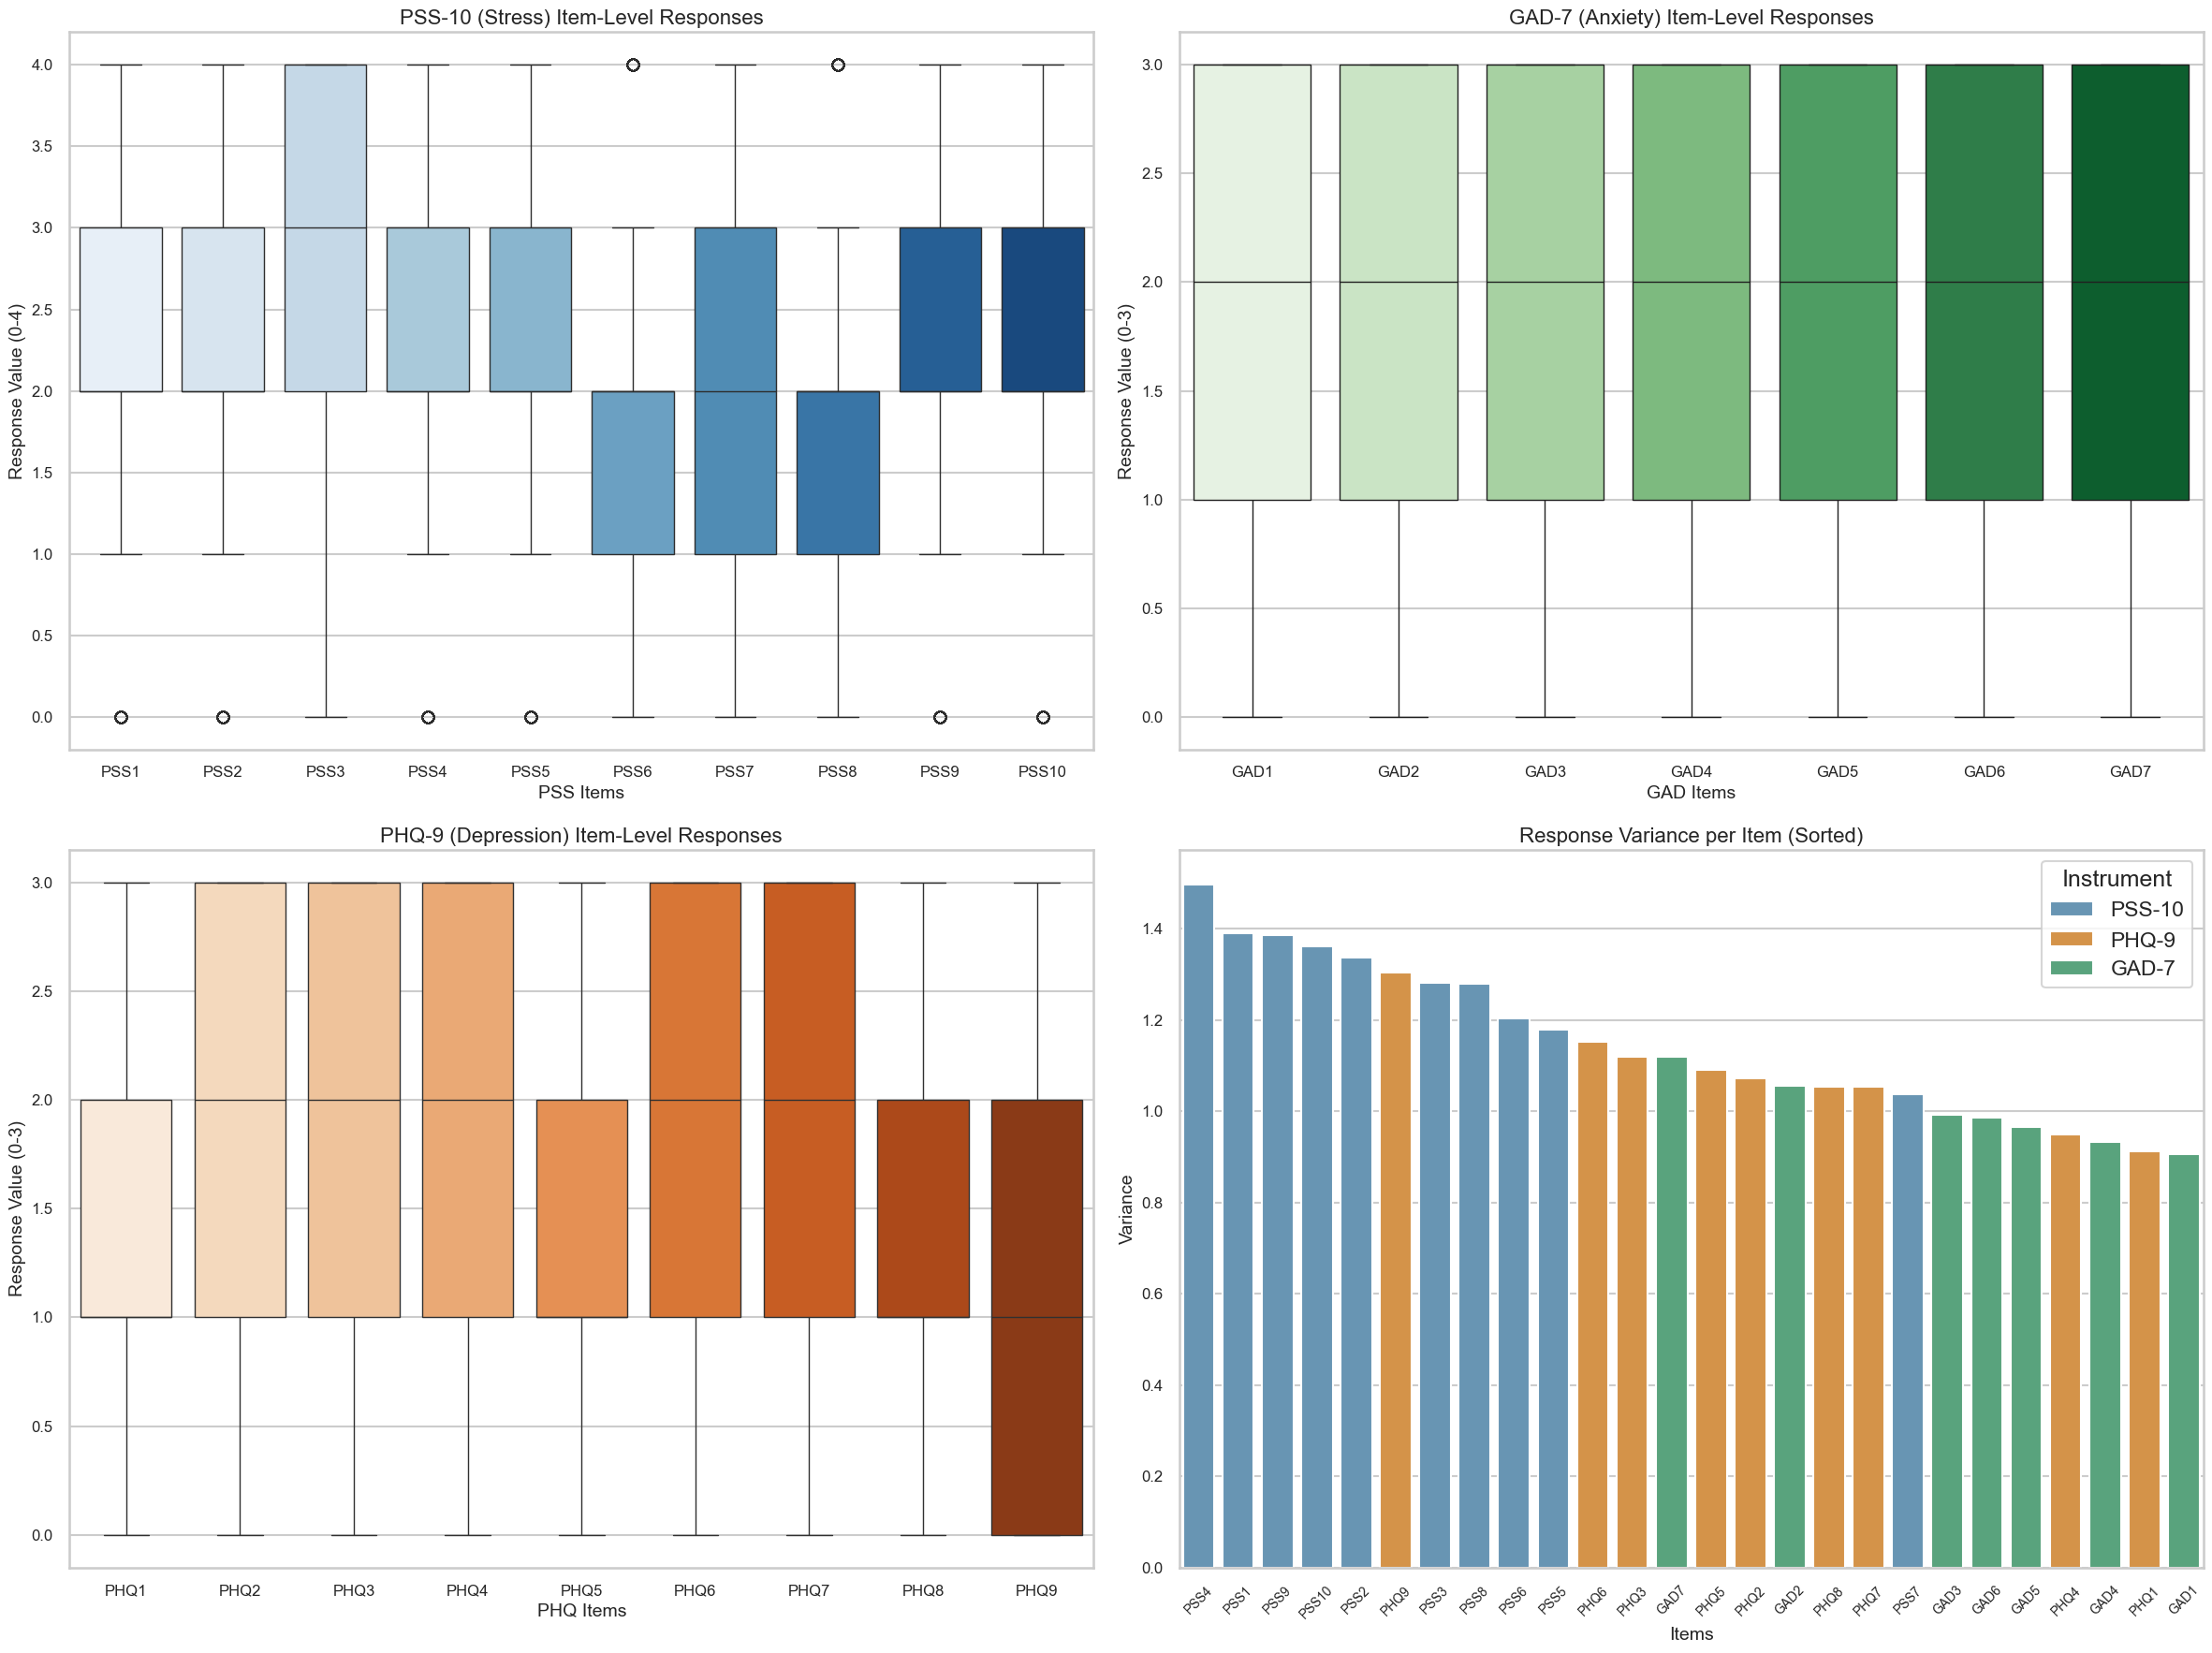

In [5]:
# 4. ITEM-LEVEL ANALYSIS (Boxplots & Variance comparison)
fig, axes = plt.subplots(2, 2, figsize=(24, 18))

# PSS Boxplots
pss_cols = [f'PSS{i}' for i in range(1, 11)]
sns.boxplot(data=df[pss_cols], palette='Blues', ax=axes[0, 0])
axes[0, 0].set_title('PSS-10 (Stress) Item-Level Responses', fontsize=16)
axes[0, 0].set_xlabel('PSS Items')
axes[0, 0].set_ylabel('Response Value (0-4)')

# GAD Boxplots
gad_cols = [f'GAD{i}' for i in range(1, 8)]
sns.boxplot(data=df[gad_cols], palette='Greens', ax=axes[0, 1])
axes[0, 1].set_title('GAD-7 (Anxiety) Item-Level Responses', fontsize=16)
axes[0, 1].set_xlabel('GAD Items')
axes[0, 1].set_ylabel('Response Value (0-3)')

# PHQ Boxplots
phq_cols = [f'PHQ{i}' for i in range(1, 10)]
sns.boxplot(data=df[phq_cols], palette='Oranges', ax=axes[1, 0])
axes[1, 0].set_title('PHQ-9 (Depression) Item-Level Responses', fontsize=16)
axes[1, 0].set_xlabel('PHQ Items')
axes[1, 0].set_ylabel('Response Value (0-3)')

# Item Variance Comparison
all_items = pss_cols + gad_cols + phq_cols
item_vars = df[all_items].var().reset_index()
item_vars.columns = ['Item', 'Variance']
item_vars['Scale'] = item_vars['Item'].apply(lambda x: 'PSS-10' if 'PSS' in x else ('GAD-7' if 'GAD' in x else 'PHQ-9'))
item_vars = item_vars.sort_values(by='Variance', ascending=False)

sns.barplot(data=item_vars, x='Item', y='Variance', hue='Scale', dodge=False,
            palette={'PSS-10': '#5C97BF', 'GAD-7': '#4DAF7C', 'PHQ-9': '#EB9532'}, ax=axes[1, 1])
axes[1, 1].set_title('Response Variance per Item (Sorted)', fontsize=16)
axes[1, 1].set_xlabel('Items')
axes[1, 1].set_ylabel('Variance')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=10)
axes[1, 1].legend(title='Instrument')

plt.tight_layout()
plt.show()

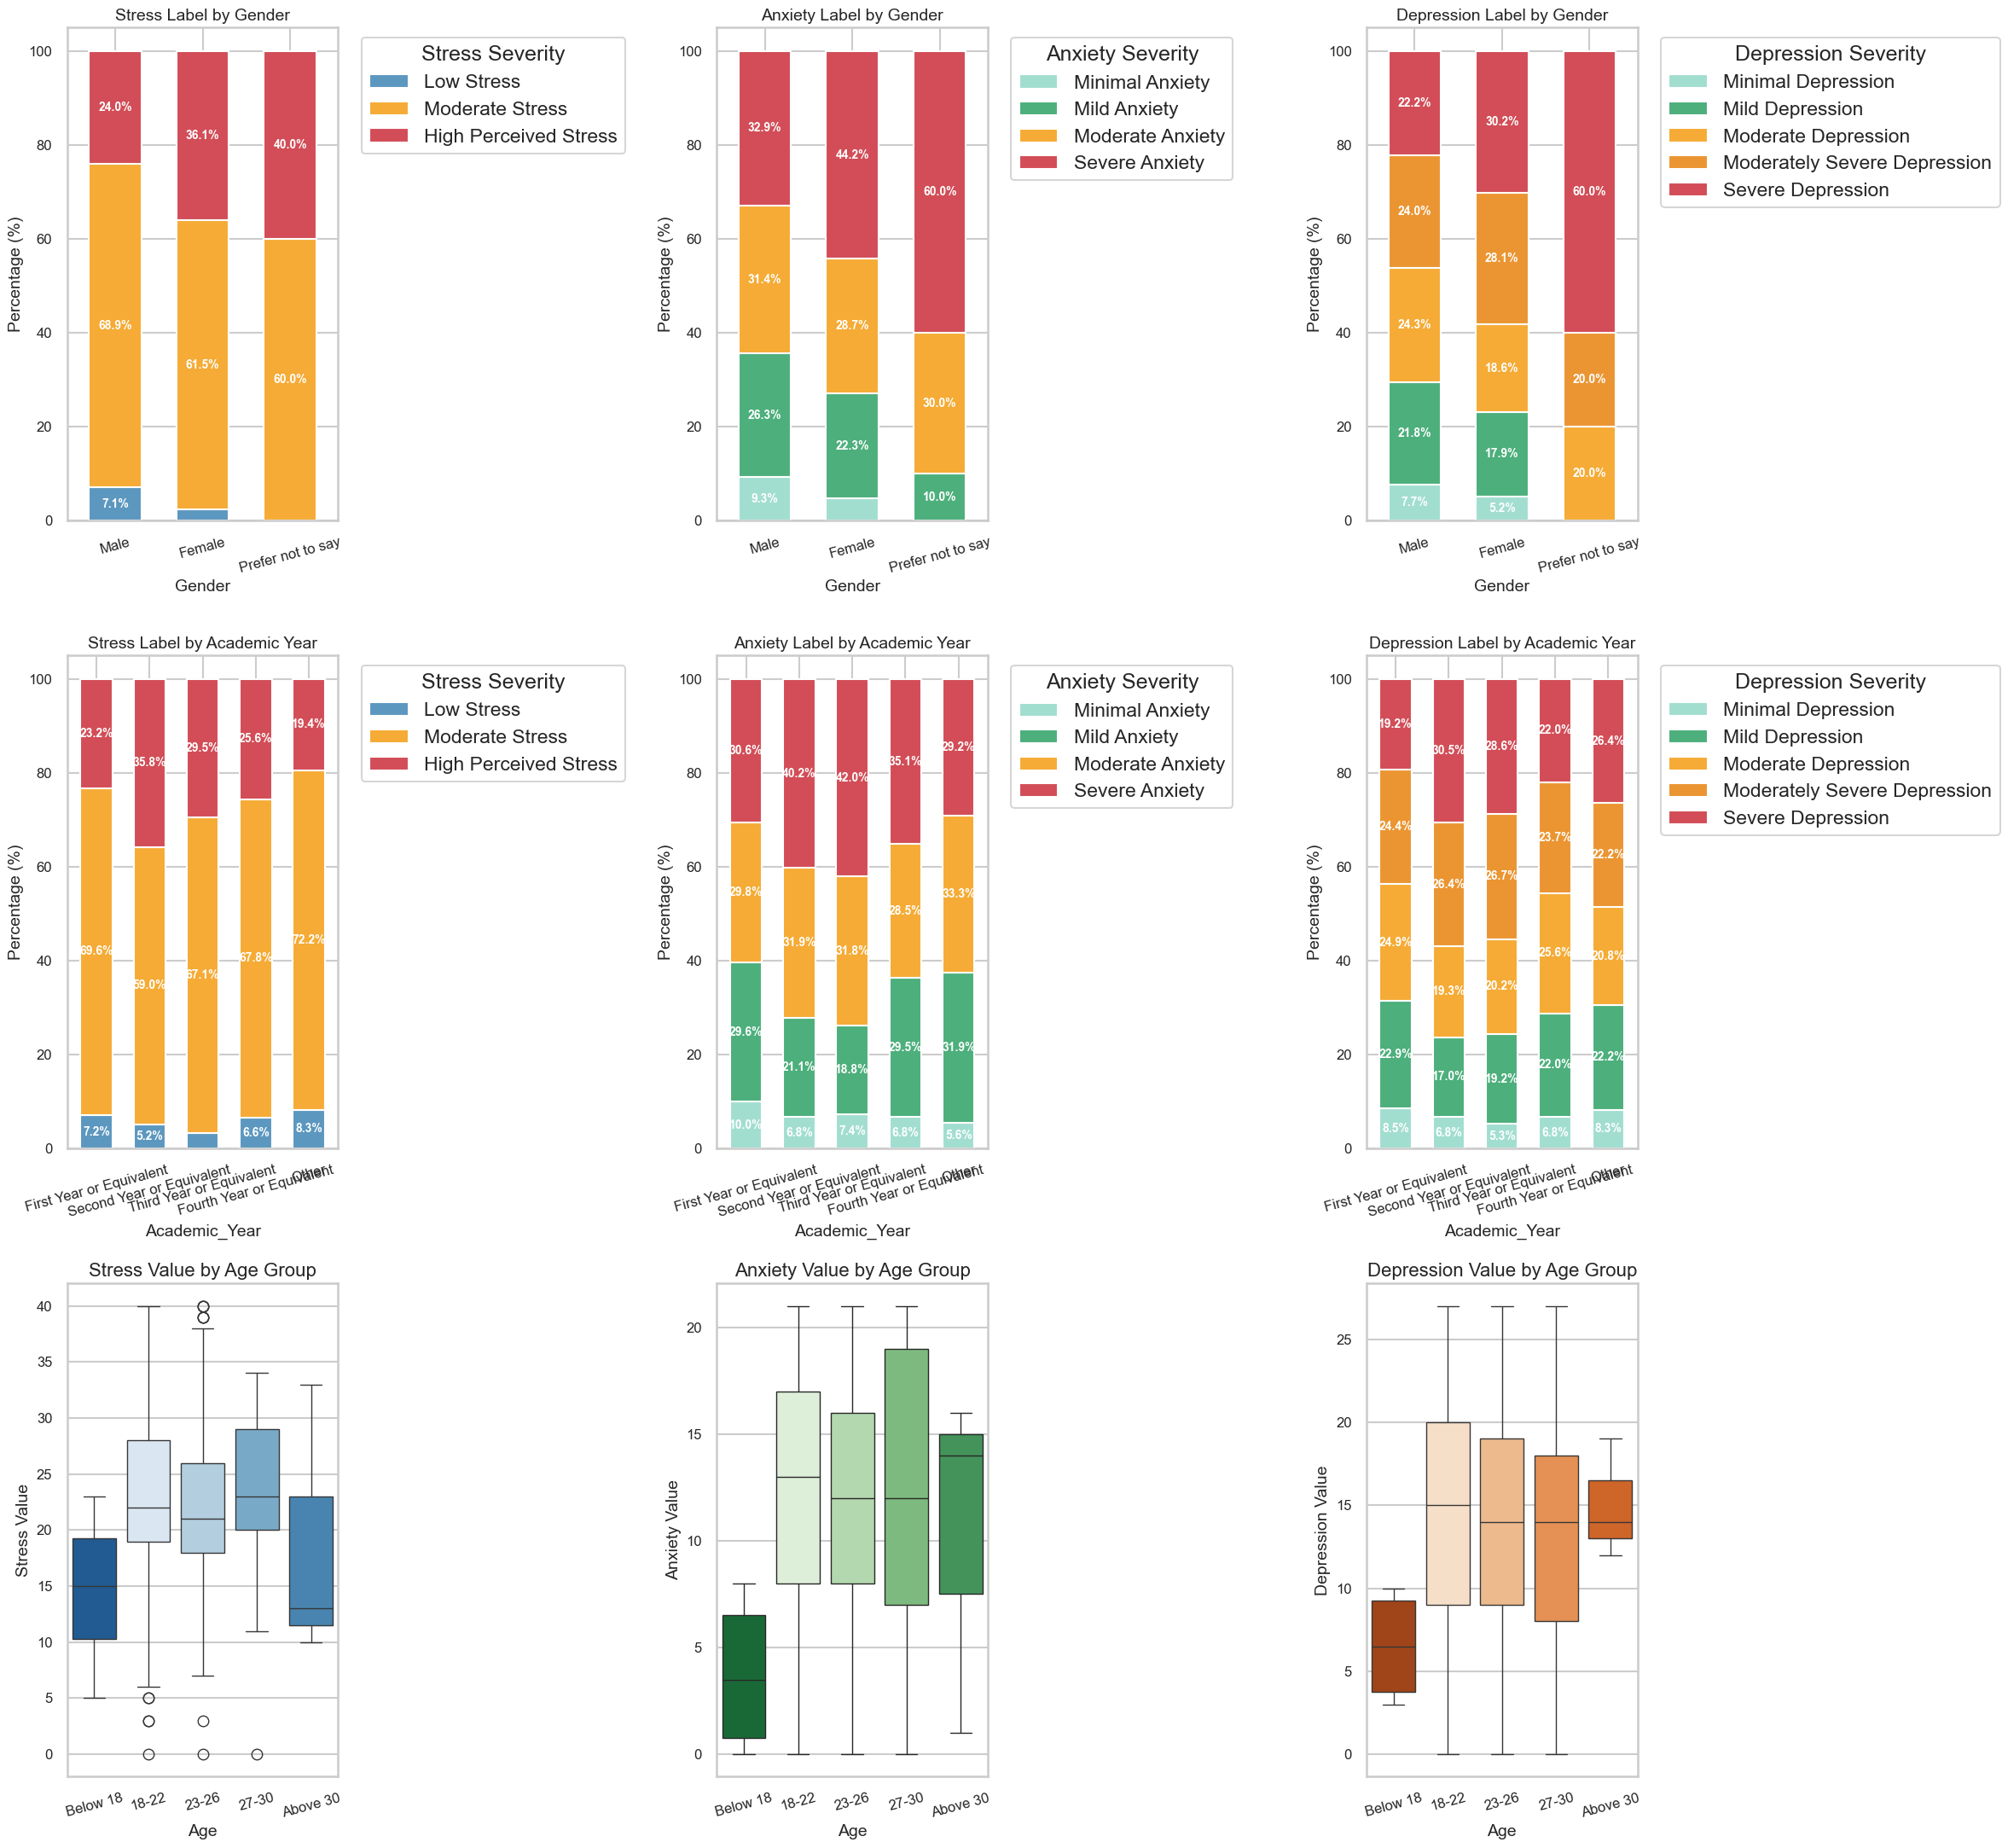

In [6]:
# Helper function for plotting normalized stacked percent bar charts
def plot_stacked_pct(df, group_col, label_col, order, palette, ax, title):
    ct = pd.crosstab(df[group_col], df[label_col], normalize='index') * 100
    ct = ct[order]
    
    # Order groups logically
    if group_col == 'Academic_Year':
        year_order = ['First Year or Equivalent', 'Second Year or Equivalent', 
                      'Third Year or Equivalent', 'Fourth Year or Equivalent', 'Other']
        ct = ct.reindex([y for y in year_order if y in ct.index])
    elif group_col == 'Gender':
        gender_order = ['Male', 'Female', 'Prefer not to say']
        ct = ct.reindex([g for g in gender_order if g in ct.index])
        
    ct.plot(kind='bar', stacked=True, color=[palette[c] for c in order], ax=ax, width=0.6)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(group_col)
    ax.set_ylabel('Percentage (%)')
    ax.legend().remove()
    ax.tick_params(axis='x', rotation=15)
    
    # Add text percentages inside segments
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 5.0: # Only draw values if segment is large enough to read
            x, y = p.get_xy()
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', fontsize=10, color='white', weight='bold')

# 5. DEMOGRAPHIC SPLITS (Gender, Academic Year & Age)
fig, axes = plt.subplots(3, 3, figsize=(24, 22))

# Row 1: Gender splits
plot_stacked_pct(df, 'Gender', 'Stress Label', stress_order, stress_palette, axes[0, 0], 'Stress Label by Gender')
axes[0, 0].legend(title='Stress Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plot_stacked_pct(df, 'Gender', 'Anxiety Label', anxiety_order, anxiety_palette, axes[0, 1], 'Anxiety Label by Gender')
axes[0, 1].legend(title='Anxiety Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plot_stacked_pct(df, 'Gender', 'Depression Label', depression_order, depression_palette, axes[0, 2], 'Depression Label by Gender')
axes[0, 2].legend(title='Depression Severity', bbox_to_anchor=(1.05, 1), loc='upper left')

# Row 2: Academic Year splits
plot_stacked_pct(df, 'Academic_Year', 'Stress Label', stress_order, stress_palette, axes[1, 0], 'Stress Label by Academic Year')
axes[1, 0].legend(title='Stress Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plot_stacked_pct(df, 'Academic_Year', 'Anxiety Label', anxiety_order, anxiety_palette, axes[1, 1], 'Anxiety Label by Academic Year')
axes[1, 1].legend(title='Anxiety Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plot_stacked_pct(df, 'Academic_Year', 'Depression Label', depression_order, depression_palette, axes[1, 2], 'Depression Label by Academic Year')
axes[1, 2].legend(title='Depression Severity', bbox_to_anchor=(1.05, 1), loc='upper left')

# Row 3: Age group splits (Boxplots of raw totals)
age_order = ['Below 18', '18-22', '23-26', '27-30', 'Above 30']
age_order = [a for a in age_order if a in df['Age'].unique()]

sns.boxplot(data=df, x='Age', y='Stress Value', order=age_order, hue='Age', legend=False, ax=axes[2, 0], palette='Blues')
axes[2, 0].set_title('Stress Value by Age Group')
axes[2, 0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='Age', y='Anxiety Value', order=age_order, hue='Age', legend=False, ax=axes[2, 1], palette='Greens')
axes[2, 1].set_title('Anxiety Value by Age Group')
axes[2, 1].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='Age', y='Depression Value', order=age_order, hue='Age', legend=False, ax=axes[2, 2], palette='Oranges')
axes[2, 2].set_title('Depression Value by Age Group')
axes[2, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

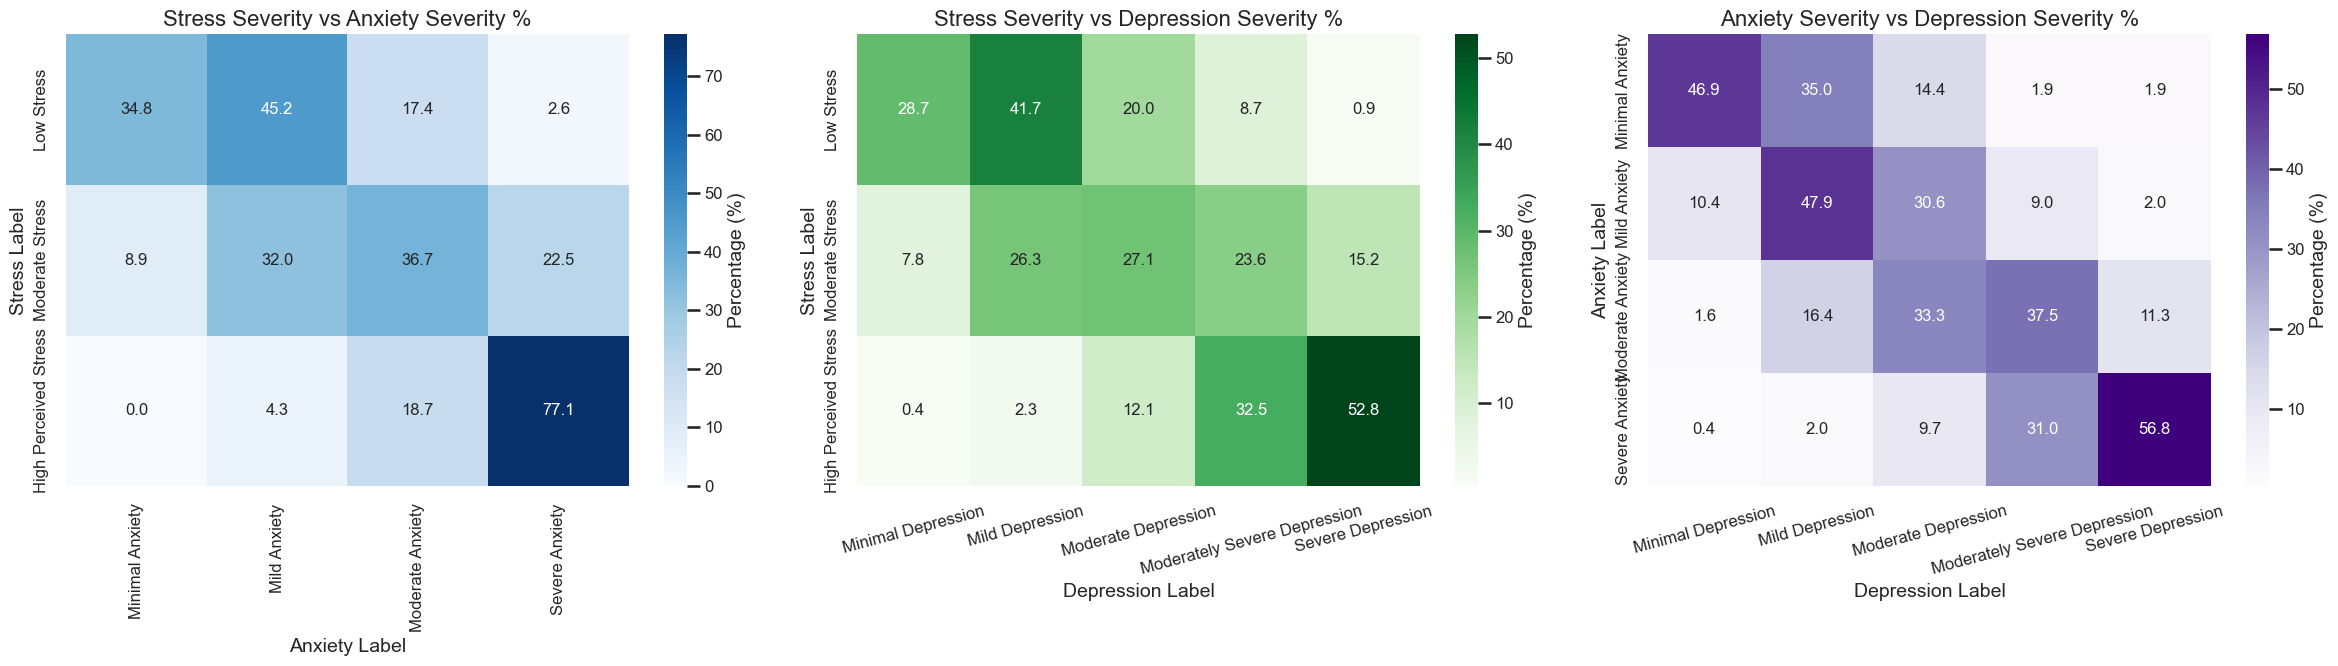

In [7]:
# 6. COMORBIDITY CROSSTABS (Row-normalised heatmaps)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 1. Stress vs Anxiety
ct_stress_anxiety = pd.crosstab(df['Stress Label'], df['Anxiety Label'], normalize='index') * 100
ct_stress_anxiety = ct_stress_anxiety.reindex(stress_order)[anxiety_order]
sns.heatmap(ct_stress_anxiety, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Percentage (%)'}, ax=axes[0], annot_kws={'size': 12})
axes[0].set_title('Stress Severity vs Anxiety Severity %')
axes[0].set_xlabel('Anxiety Label')
axes[0].set_ylabel('Stress Label')

# 2. Stress vs Depression
ct_stress_dep = pd.crosstab(df['Stress Label'], df['Depression Label'], normalize='index') * 100
ct_stress_dep = ct_stress_dep.reindex(stress_order)[depression_order]
sns.heatmap(ct_stress_dep, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': 'Percentage (%)'}, ax=axes[1], annot_kws={'size': 12})
axes[1].set_title('Stress Severity vs Depression Severity %')
axes[1].set_xlabel('Depression Label')
axes[1].set_ylabel('Stress Label')
axes[1].tick_params(axis='x', rotation=15)

# 3. Anxiety vs Depression
ct_anxiety_dep = pd.crosstab(df['Anxiety Label'], df['Depression Label'], normalize='index') * 100
ct_anxiety_dep = ct_anxiety_dep.reindex(anxiety_order)[depression_order]
sns.heatmap(ct_anxiety_dep, annot=True, fmt='.1f', cmap='Purples', cbar_kws={'label': 'Percentage (%)'}, ax=axes[2], annot_kws={'size': 12})
axes[2].set_title('Anxiety Severity vs Depression Severity %')
axes[2].set_xlabel('Depression Label')
axes[2].set_ylabel('Anxiety Label')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

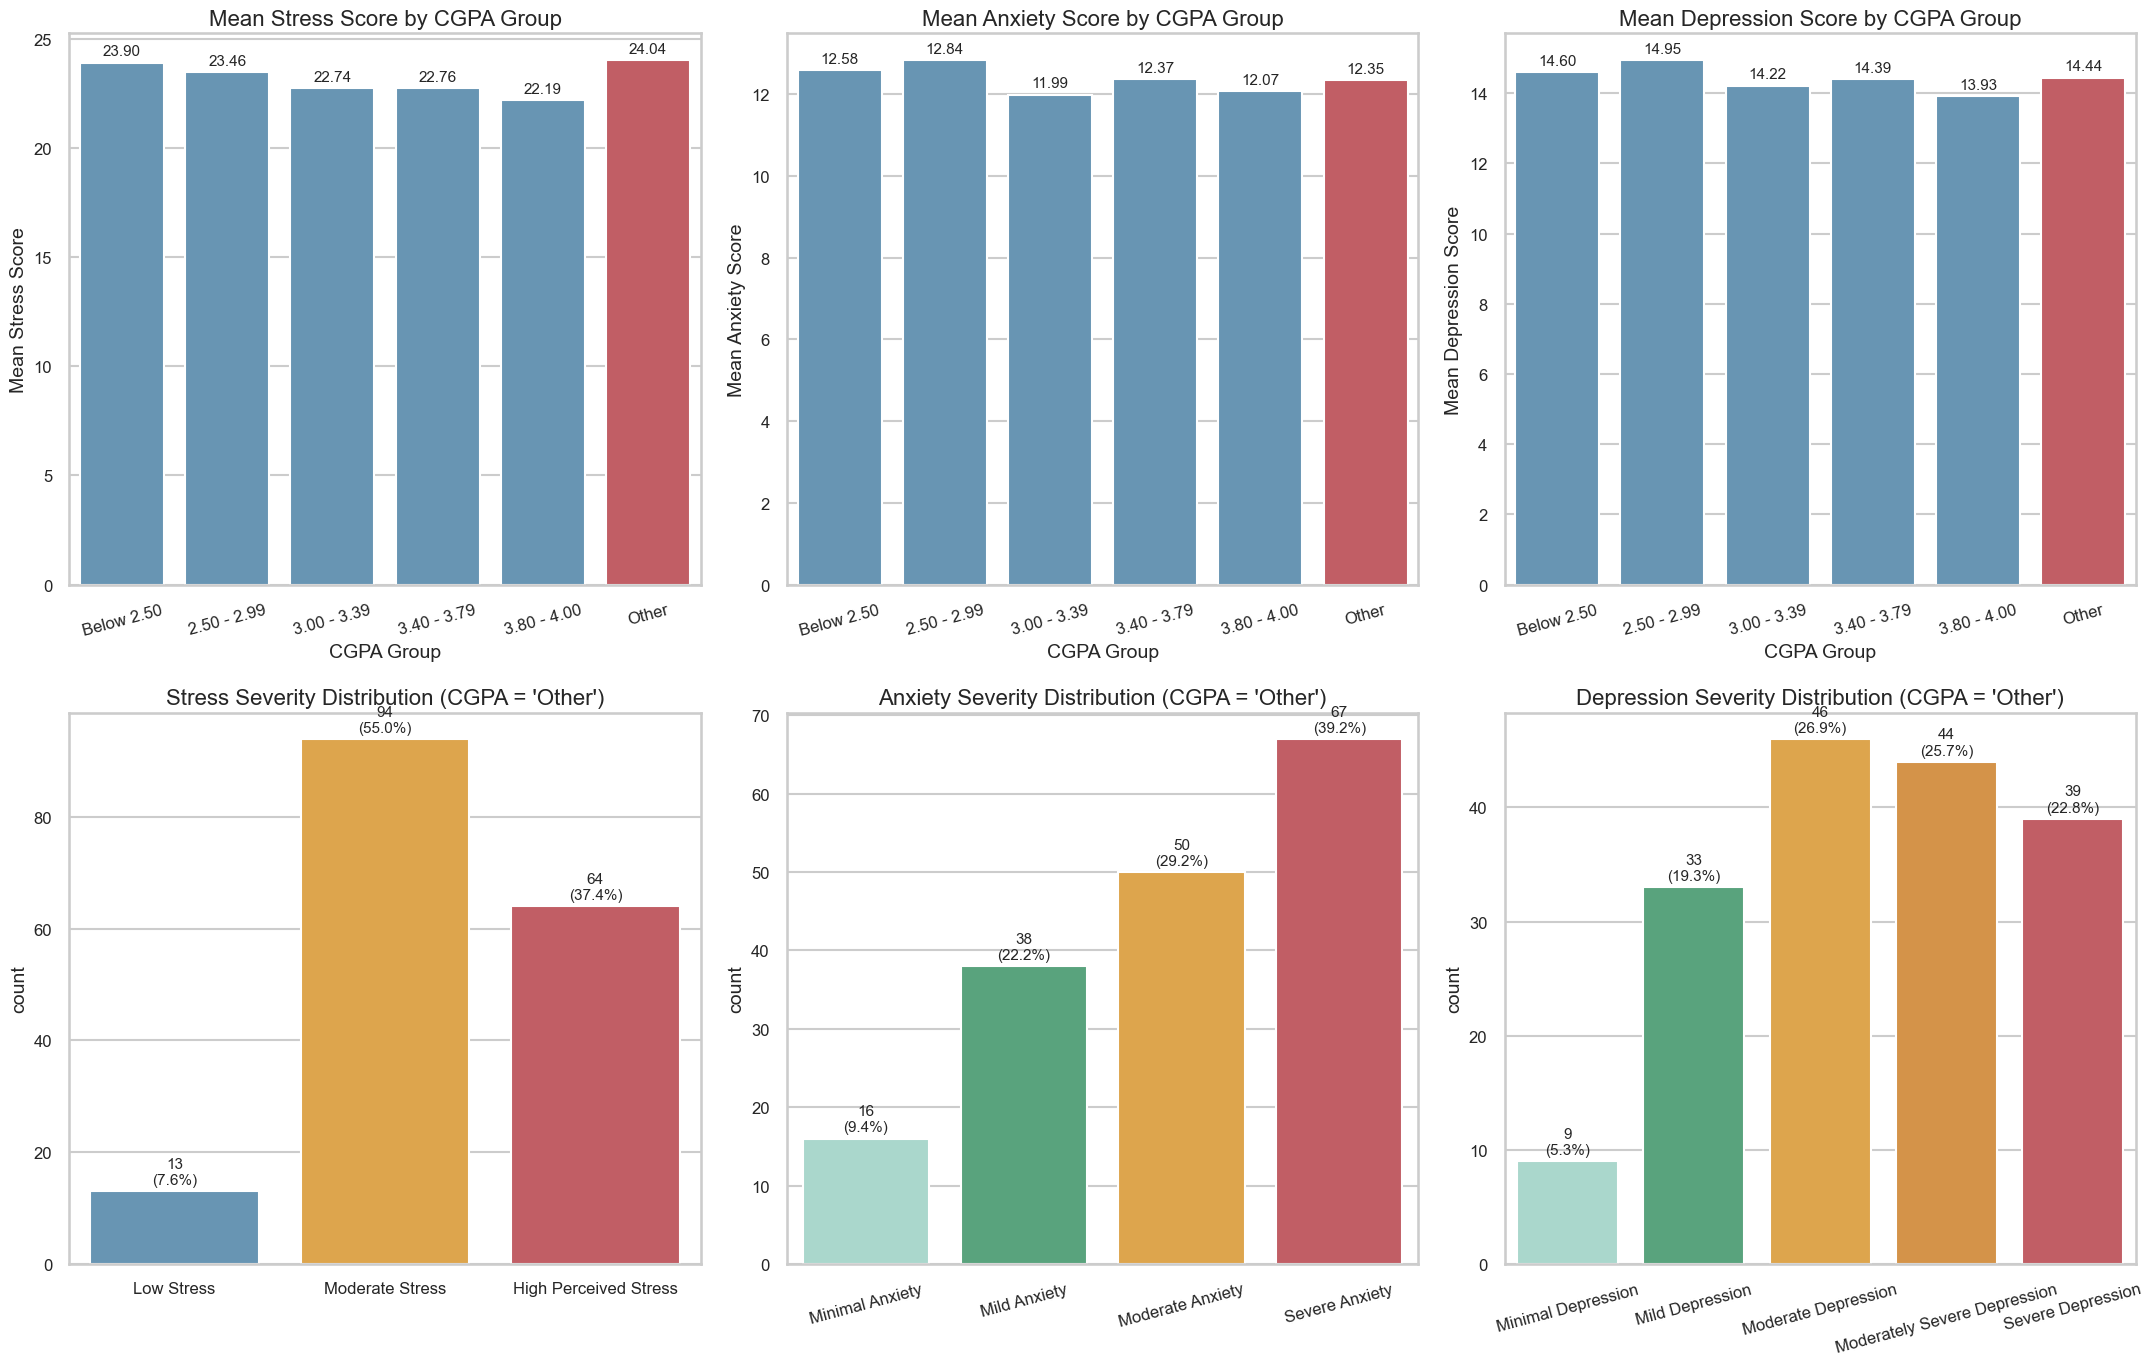

In [8]:
# 7. CGPA 'Other' INSPECTION
cgpa_order = ['Below 2.50', '2.50 - 2.99', '3.00 - 3.39', '3.40 - 3.79', '3.80 - 4.00', 'Other']
colors = ['#5C97BF' if c != 'Other' else '#D24D57' for c in cgpa_order]

fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# Mean Stress by CGPA
mean_stress = df.groupby('Current_CGPA')['Stress Value'].mean().reindex(cgpa_order)
sns.barplot(x=mean_stress.index, y=mean_stress.values, hue=mean_stress.index, palette=colors, legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Mean Stress Score by CGPA Group')
axes[0, 0].set_xlabel('CGPA Group')
axes[0, 0].set_ylabel('Mean Stress Score')
axes[0, 0].tick_params(axis='x', rotation=15)
for p in axes[0, 0].patches:
    val = p.get_height()
    axes[0, 0].annotate(f'{val:.2f}', (p.get_x() + p.get_width() / 2., val),
                        ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

# Mean Anxiety by CGPA
mean_anxiety = df.groupby('Current_CGPA')['Anxiety Value'].mean().reindex(cgpa_order)
sns.barplot(x=mean_anxiety.index, y=mean_anxiety.values, hue=mean_anxiety.index, palette=colors, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Mean Anxiety Score by CGPA Group')
axes[0, 1].set_xlabel('CGPA Group')
axes[0, 1].set_ylabel('Mean Anxiety Score')
axes[0, 1].tick_params(axis='x', rotation=15)
for p in axes[0, 1].patches:
    val = p.get_height()
    axes[0, 1].annotate(f'{val:.2f}', (p.get_x() + p.get_width() / 2., val),
                        ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

# Mean Depression by CGPA
mean_dep = df.groupby('Current_CGPA')['Depression Value'].mean().reindex(cgpa_order)
sns.barplot(x=mean_dep.index, y=mean_dep.values, hue=mean_dep.index, palette=colors, legend=False, ax=axes[0, 2])
axes[0, 2].set_title('Mean Depression Score by CGPA Group')
axes[0, 2].set_xlabel('CGPA Group')
axes[0, 2].set_ylabel('Mean Depression Score')
axes[0, 2].tick_params(axis='x', rotation=15)
for p in axes[0, 2].patches:
    val = p.get_height()
    axes[0, 2].annotate(f'{val:.2f}', (p.get_x() + p.get_width() / 2., val),
                        ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

# Filter for CGPA = 'Other'
df_other = df[df['Current_CGPA'] == 'Other']

# Stress labels for 'Other'
sns.countplot(data=df_other, x='Stress Label', order=stress_order, hue='Stress Label', palette=stress_palette, legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Stress Severity Distribution (CGPA = 'Other')")
axes[1, 0].set_xlabel('')
for p in axes[1, 0].patches:
    height = p.get_height()
    pct = (height / len(df_other)) * 100
    axes[1, 0].annotate(f'{int(height)}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

# Anxiety labels for 'Other'
sns.countplot(data=df_other, x='Anxiety Label', order=anxiety_order, hue='Anxiety Label', palette=anxiety_palette, legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Anxiety Severity Distribution (CGPA = 'Other')")
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=15)
for p in axes[1, 1].patches:
    height = p.get_height()
    pct = (height / len(df_other)) * 100
    axes[1, 1].annotate(f'{int(height)}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

# Depression labels for 'Other'
sns.countplot(data=df_other, x='Depression Label', order=depression_order, hue='Depression Label', palette=depression_palette, legend=False, ax=axes[1, 2])
axes[1, 2].set_title("Depression Severity Distribution (CGPA = 'Other')")
axes[1, 2].set_xlabel('')
axes[1, 2].tick_params(axis='x', rotation=15)
for p in axes[1, 2].patches:
    height = p.get_height()
    pct = (height / len(df_other)) * 100
    axes[1, 2].annotate(f'{int(height)}\n({pct:.1f}%)', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()